# Unsupervised training for hidden Markov models

The goal of this activity is to implement unsupervised training of a hidden Markov model (the Baum-Welch algorithm, solution to HMM Problem 3) and use this to discover a way to classify characters (letters and spaces).

Before we get started, we should take note that we'll be dealing with a large amount of data and long products of probabilities. To avoid underflow, all of our computation will be in *log probabilities*. Part of the challenge for you today is not only understanding the formulas for the Baum-Welch algorithm but also translating them into log probabilities: products of probabilities become sums of log probabilities, and ratios of probabilities become differences of log probabilities. Some of the formulas, however, involve *sums of probabilities*. To make this easier, I'm providing the following function which computes the log of a sum of probabilities, given the logs of the individual probabilities. That is, it computes

$\log \sum_{i=0}^{n-1} p_i$

Given

$\log p_0, \log p_1, \ldots \log p_{n-1}$

To compute the log sum given log probabilities, we use the following formula:

$\begin{array}{rcl}
\lg \displaystyle\sum_{i=0}^{n-1} x_i &=& \lg (x_0 + x_i + \cdots + x_{n-1}) \\ \\
&=& \lg x_0 + \lg \left(1 + \displaystyle\sum_{i=1}^{n-1} \frac{x_i}{x_0} \right) \\ \\
&=& \lg x_0 + \lg\left(1 + \displaystyle\sum_{i=1}^{n-1} 2^{\lg x_i - \lg x_0} \right) 
\end{array}$

Moreover, we (reverse) sort the the log probabilities first so that $\lg x_i < \lg x_0$ and $2^{\lg x_i - \lg x_0} \in [0, 1]$. 


In [62]:
import os
import math
def log_sum(terms):
    terms = terms.copy() # before we sort make a copy---don't mess up the original
    if len(terms) == 0 :
        return 1  
    terms.sort(reverse=True)
    try :
        return terms[0] + math.log1p(sum([math.exp(x - terms[0]) for x in terms[1:]]))
    except OverflowError :
        print("********")
        print(terms)
        print([x - terms[0] for x in terms[1:]])
        print([math.exp(x - terms[0]) for x in terms[1:]])
        print(sum([math.exp(x - terms[0]) for x in terms[1:]]))
        print(math.log1p(sum([math.exp(x - terms[0]) for x in terms[1:]])))

As a quick demonstration...

In [63]:
# Original probabilities
probs = [0.05, 0.25, 0.001, 0.00125]
# Log probabilities
log_probs = [math.log(p) for p in probs]
# Directly compute the sum, and display it with its log
prob_sum = sum(probs)
print(prob_sum, math.log(prob_sum))
# Compute the log sum, and display it with its coversion back from logs
log_prob_sum = log_sum(log_probs)
print(math.exp(log_prob_sum), log_prob_sum)

0.30224999999999996 -1.196500789487235
0.30224999999999996 -1.196500789487235


## Setting up the symbol set, training data, and model

In this experiment, we use lowercase letters plus spaces as the set of symbols, which is $V$ in the formal HMM description. We also want to be able to use numeric indices for symbols, so we have a dictionary that converts characters to indices in the range $[0, 27)$.

In [64]:
alphabet = 'abcdefghijklmnopqrstuvwxyz '
alphabet_to_index = { alphabet[i]:i for i in range(len(alphabet)) }

Our training text is found in a file in my public folder for this course. We convert the characters to lower case and filter out anything that is not a letter or a space. We also convert all characters to indices into `alphabet`.

In [65]:
source_file = open('/homes/tvandrun/Public/cs384/hmm_em/roni.txt')
observations = []
for line in source_file :
    for c in line :
        c = c.lower()
        if c in alphabet :
            observations.append(alphabet_to_index[c])

We use $N$ (number of states), $M$ (number of symbols), $T$ (length of training data), and $\varepsilon$ (tolerance) as global variables. Specifically $M = 2$ is our guess that there may be two interesting classes of characters. 

In [66]:
N = 3
M = len(alphabet)
T = len(observations)
epsilon = 0.0001

The model itself is a triple, consisting in the initial state probabilities, the transition probabilities, and the emission probabilities. Here is the example we'll use in testing the pieces of our code in this activity:

In [67]:
pi_raw = [0.6142857142857143, 0.1857142857142857, 0.2]
a_raw = [[0.2857142857142857, 0.5142857142857143, 0.2], [0.4714285714285714, 0.32857142857142855, 0.2], [0.3, 0.4, 0.3]]
b_raw = [[0.03125, 0.0625, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 
          0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 0.03125, 0.03125, 
          0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 0.0625, 0.03125], 
         [0.03125, 0.0625, 0.0625, 0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 0.03125, 0.03125, 
          0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 0.0625, 
          0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125],
         [0.03125, 0.0625, 0.0625, 0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 0.03125, 0.03125, 
          0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.0625, 0.03125, 0.0625, 
          0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125]]

We called these "raw" because they are regular probability values, where as we want to work exclusively with *log probabilities*. Let's convert all these.

In [68]:
pi = [math.log(pi_raw[i]) for i in range(N)]
print(pi)
a = [[math.log(a_raw[i][j]) for j in range(N)] for i in range(N)]
print(a)
b = [[math.log(b_raw[i][k]) for k in range(M)] for i in range(N)]
print(b)

[-0.4872951263557965, -1.6835458845878224, -1.6094379124341003]
[[-1.252762968495368, -0.6649763035932489, -1.6094379124341003], [-0.7519876805828788, -1.1130010261202092, -1.6094379124341003], [-1.2039728043259361, -0.916290731874155, -1.2039728043259361]]
[[-3.4657359027997265, -2.772588722239781, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -2.772588722239781, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -2.772588722239781, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -2.772588722239781, -3.4657359027997265, -2.772588722239781, -3.4657359027997265], [-3.4657359027997265, -2.772588722239781, -2.772588722239781, -3.4657359027997265, -3.4657359027997265, -3.4657359027997265, -2.772588722239781, -3.4657359027997265, -3.46573590

As we use and update this model, it should always be that $pi$ and each column in $A$ and $B$ should be proper probability distributions. The following `sanity_check()` converts the model to regular probabilities and asserts that the probability distributions sum to 1 (or, within an epsilon of 1).

In [69]:
def sanity_check(pi, a, b) :
    N = len(pi)
    M = len(b[0])
    assert abs(1.0-sum([math.exp(pi[i]) for i in range(N)])) < epsilon
    for i in range(N) :
        assert abs(1.0 - sum([math.exp(a[i][j]) for j in range(N)])) < epsilon
        assert abs(1.0 - sum([math.exp(b[i][k]) for k in range(M)])) < epsilon

Let's check the model we have. (No response is good.)

In [70]:
sanity_check(pi, a, b)

## The forward algorithm

Now it's time to implement the forward algorithm. Recall that $\alpha_t(i)$ is
the probability of the observation sequence up to and including time $t$, 
supposing the state at time $t$ is $q_i$. 
The recursive characterization is

$\alpha_t (i) = 
 P(\bar{\mathcal{O}}[:t+1], S_t = q_i \ | \lambda) =
\left\{
\begin{array}{ll}
\pi_i \cdot b_i(\mathcal{O}_0) & \mbox{if $t=0$} \\ \\ \\ \\
\left(\displaystyle\sum_{j=0}^{N-1} \alpha_{t-1}(j) \cdot a_{ji}\right) \cdot b_i(\mathcal{O}_t) &
\mbox{otherwise}
\end{array}
\right.$

But to implement this, convert the formula to use log probabilities.

Finish the function `compute_alphas()` which takes a model  and observation sequence and returns the $\alpha$ table.


In [71]:
def compute_alphas(pi, a, b, observations) :
    alphas = [[None for i in range(N)] for t in range(T)]
    for i in range(N) :
        alphas[0][i] = pi[i] + b[i][observations[0]]
    for t in range(1, T) :
        for i in range(N) :
            alphas[t][i] = log_sum([alphas[t-1][j] + a[j][i] for j in range(N)])+(b[i][observations[t]])
    return alphas

Try it out with our current model. 

In [72]:
alphas = compute_alphas(pi, a, b, observations)

The "final answer"---that is, the probability of the entire sequence---is the sum of the alphas at $T-1$. Remember that would be the sum of the *probabilities*, but we have *log probabilities*. 

In [73]:
log_sum(alphas[T-1])

-91920.55379071012

Your result should be `-92029.57604683952`.

## The backward algorithm

What is better than one algorithm for computing the probability of an observation sequence? *Two algorithms* for computing the observation sequence, of course. (The real reason for two algorithms, you'll remember for class, is that the Baum-Welch algorithm for Problem 3 relies on both algorithms for Problem 1.) 

Recall that $\beta_t(i)$ means the probability of observing the observation sequence *suffix* starting at time $t+1$ assuming that the process is in state $q_i$ at time $t$. The recursive characterization is

$\beta_t(i) =
P(\bar{\mathcal{O}}[t+1:] \ | \ S_t = q_i) =
\left\{
\begin{array}{ll}
1 & \mbox{if $t = T-1$} \\ \\ \\ \\
\displaystyle\sum_{j=0}^{N-1} a_{ij} \cdot b_j(\mathcal{O}_{t+1}) \cdot \beta_{t+1}(j) &
\mbox{if $t < T-1$} 
\end{array}
\right. $

Finish the function `compute_betas()` which takes a model and computes the beta table. Remember to translate the recursive characterization to work with log probabilities.

In [74]:
def compute_betas(pi, a, b, observations) :
    N = len(pi)
    T = len(observations)

    betas = [[None for i in range(N)] for t in range(T)]
    for i in range(N) :
        betas[T-1][i] = 0
    for t in reversed(range(T-1)) :
        for i in range(N) :
            betas[t][i] = log_sum([a[i][j]+b[j][observations[t+1]]+betas[t+1][j] for j in range(N)])
    
    return betas

The "final answer" is the sum of the betas in column $T = 0$, each multipied by the probability the corresponding state having emitted $\mathcal{O}_0$ and the probabilities of the process having started in that state:

$P(\bar{\mathcal{O}} \ | \lambda) = \sum_{i=0}^{N-1} \pi_i \cdot b_i(\mathcal{O}_0) \cdot \beta_0(i)$

But the backward algorithm should always give the same result as the forward algorithm. The following function computes the "final answers" for both the forward and backward algorithms (given a model and already-computed alpha and beta tables), checks that they are equal (or "close"), and returns the result. We call this `log_likelihood()` because it computes the log likelihood/probabilitiy of the observation sequence.

In [75]:
def log_likelihood(pi, a, b, alphas, betas, observations) :
    N = len(pi)
    T = len(observations)

    log_like_alphas = log_sum(alphas[T-1])
    log_like_betas = log_sum([pi[i] + b[i][observations[0]] + betas[0][i]
                              for i in range(N)])
    if not(abs(log_like_alphas - log_like_betas) < .1) :
        print(log_like_alphas)
        print(log_like_betas)
        print(log_like_alphas - log_like_betas)
    assert abs(log_like_alphas - log_like_betas) < .1
    return log_like_alphas

Once again, the result should be `-92029.57604683952`:

In [76]:
betas = compute_betas(pi, a, b, observations)
log_like = log_likelihood(pi, a, b, alphas, betas, observations)
print(log_like)

-91920.55379071012


## Computing the latent variables (E-step)

The Baum-Welch algorithm is a version of EM. In the "expectation" step, we compute the *expected value* of the latent variables. In this problem, the latent variables are *which state was the process in at step $t$?* and the related variables of *which transition happened between step $t$ and step $t+1$?* These questions are represented by gammas and xis, respectively.

Recall that $\xi_t(i, j)$ is the probability that the process was in state $q_i$ at time $t$ and state $q_j$ at time $t + 1$. This uses the alpha table to consider the probability of ending up in state $q_i$ from start to time $t$ and the beta table to consider the probability of going from state $q_j$ from time $t+1$ to the end:

$
\begin{array}{lcccl}
\xi_t(i,j) &=&
P(S_t = q_i, S_{t+1} = q_j \ | \ \bar{\mathcal{O}}, \lambda) &=&
\dfrac{P(S_t = q_i, S_{t+1} = q_j, \bar{\mathcal{O}} \ | \lambda)}{P(\bar{\mathcal{O}} \ | \ \lambda)} \\ \\
&&&=& 
\dfrac{\alpha_t(i) \cdot a_{ij} \cdot b_j(\mathcal{O}_{t+1})\cdot \beta_{t+1}(j)}
{\displaystyle\sum_{\mathit{ii}} \sum_{\mathit{jj}} \alpha_t(\mathit{ii}) \cdot a_{\mathit{\mathit{ii}} \ \mathit{\mathit{jj}}} 
\cdot b_{\mathit{jj}}(\mathcal{O}_{t+1}) \cdot \beta_{t+1}(\mathit{jj})}
\end{array}
$

We're going to compute the xi table with the function below. But notice *first*, that this table has three dimensions $(t, i, j)$, not just two dimensions like all the other tables; and *second*, that the denominator is really just a recomputing of the probability of the entire observation sequence, just stated in a way that emphasizes time $t$. For efficiency, we'll assume that the log likelihood of the observation sequence is passed to the function to compute the xi table since the training function will have already computed the log likelihood when testing for convergence.

Finish the function `compute_xis()`, which takes a model and the alpha and beta tables and the log likelihood, all assumed to be already computed. Once again, don't forget to translate to log probabilities. Division in "regular probabilities" translates to subtraction in log probabilities (that is, $\log \frac{x}{y} = \log x - \log y$).

In [77]:
def compute_xis(pi, a, b, alphas, betas, log_like, observations) :
    N = len(pi)
    T = len(observations)

    return [[[ alphas[t][i]+a[i][j] + b[j][observations[t+1]]+betas[t+1][j] - log_sum([log_sum([alphas[t][ii]+a[ii][jj]+b[jj][observations[t+1]]+betas[t+1][jj] for jj in range(N)]) for ii in range(N)])
              for j in range(N)]
             for i in range(N)]
            for t in range(T-1)]


Try it for our sample model.

In [78]:
xis = compute_xis(pi, a, b, alphas, betas, log_like, observations)

To see if you've done this right, let's sample from the table. The values of the following cells should be `-1.12355011315958`, `-1.566710241313558`, and `-2.0644383619655855`.

In [79]:
print(xis[100][0][1])
print(xis[1005][1][0])
print(xis[22557][0][0])

-1.6618299257970648
-2.1204858302953653
-2.2597326282120775


Now for computing the gammas, which are relatively easy (that is, compared to to xis). Recall that $\gamma_t(i)$ is the probability that the process was in state $q_i$ at time $t$. This is the stand-in for the latent variable, the probability that the unknown value ($S_t$) is $q_i$. The formula is

$
\begin{array}{lcccl}
\gamma_t(i) &=&
P(S_t = q_i \ | \ \bar{\mathcal{O}}, \lambda) &=&
\displaystyle\sum_{j=0}^{N-1} P(S_t = q_i, S_{t+1} = q_j \ | \ \bar{\mathcal{O}}, \lambda)  \\ \\
&&&=& \displaystyle\sum_{j=0}^{N-1} \xi_t(i, j)
\end{array}
$

Finish the function `compute_gammas()`, which takes only the xi table. Remember that you are summing log probabilities.

In [80]:
def compute_gammas(xis, T, N) :
    return [[  log_sum([xis[t][i][j] for j in range(N)])
             for i in range(N)] 
            for t in range(T-1)]

Test and sample. The results should be `-0.8019182691741993`, `-0.64784633337893`, and `-0.8223371174724576`.

In [81]:
gammas = compute_gammas(xis, len(observations), N)
print(gammas[100][0])
print(gammas[1005][1])
print(gammas[22557][0])

-1.0046439367695676
-0.9437658386052439
-1.009222923067889


## Recomputing the model (M-step)

Now, using the expected values of the latent variables, we recompute the model by finding the $A$, $B$, and $\pi$ that maximize the probability of the (given) observations and (expected) state sequence. Algorithmically, this is analogous to maximum likelihood estimation:

$
\begin{array}{rclcl}
\pi_i &=& \gamma_0(i) &&\\ \\ \\
a_{i j} &=& 
\dfrac{\mbox{expected transitions from $q_i$ to $q_j$}}
{\mbox{expected transitions from $q_i$}} &=&
\dfrac{\sum_{t=0}^{T-2} \xi_t(i, j)}{\sum_{t=0}^{T-2} \gamma_t(i)} \\ \\ \\
b_i(k) &=&  
\dfrac{\mbox{expected times $q_i$ emits $v_k$}}
{\mbox{expected times in $q_i$}} &=&
\dfrac{\sum_{t=0}^{T-2} \{ \gamma_t(i) \ | \ \mathcal{O}_t = v_k \} }
{\sum_{t=0}^{T-2} \gamma_t(i) }
\end{array}
$

Note that the denominators in the $A$ and $B$ formula are the same, and they don't depend on $j$ or $k$. For efficiency, we comupte these first and reuse. 

Finish the function `maximize()`, which takes the xi and gamma tables. Don't forget to translate to log probabilities. "It is no trouble for me to write the same things to you again, and it is a safeguard for you." (Phil 3:1b)

In [82]:
def maximize(xis, gammas, observations, M) :
    N = len(gammas[0])
    T = len(observations)

    denoms = [log_sum([gammas[t][i] for t in range(T-2)]) for i in range(N)]
    pi = gammas[0]
    a = [[  log_sum([xis[t][i][j] for t in range(T-2)]) - denoms[i]
          for j in range(N)]
         for i in range(N)]
    b = [[  log_sum([gammas[t][i] for t in range(T-2) if observations[t] == k]) - denoms[i]
          for k in range(M)]
         for i in range(N)]
    sanity_check(pi, a, b)  # Make sure we have proper probability functions
    return (pi, a, b)

Let's try it on the model, xis, and gammas we have, and print the resulting model (we'll only sample from $B$).

In [83]:
(pi_new, A_new, B_new) = maximize(xis, gammas, observations, M)
print(pi_new)
print(A_new)
print(B_new[0][13], B_new[1][4])

[-0.8135129901000373, -1.3166109877303498, -1.242506407533876]
[[-1.2883613408393533, -0.6532323897644012, -1.590043571992819], [-0.7745443574462954, -1.0960872546235105, -1.5851835419693039], [-1.2338289155290934, -0.9069044254084346, -1.1872722132649294]]
-2.8502808564751163 -2.2876511325522593


You should get

```
[-0.5878344794336935, -0.8108704274773417]
[[-1.2876653963792037, -0.32284536047885126], [-0.5774885782935826, -0.8239537737662896]]
-2.859449957899 -2.2977277385787334
```

## Putting it together

Now we put the E-step and M-step together into an algorithm that iterates until the model is good enough. We're missing one piece, though: Guessing an initial model. It's best not to start with a uniform model (that is, every possibility has equal probability) because the uniform model might itself be a local maximum. Instead, we randomly scramble the probabilities. I'm providing this for you in the following function.

In [84]:
import random

fudge = 100 # The "fudge factor" to randomly permute this from being a uniform distribution

def initialize_model(N, M) :
    pi = [1.0 for i in range(N)]
    for i in range(fudge) :
        pi[random.randint(0,N-1)] += 1
    for i in range(N) :
        pi[i] /= (N+fudge)
    for i in range(N):
        pi[i] = math.log(pi[i])
    
    a = [[1.0 for j in range(N)] for i in range(N)]
    for i in range(N) :
        for j in range(fudge) :
            a[i][random.randint(0, N-1)] += 1
        for j in range(N) :
            a[i][j] /= (N+fudge)
        for j in range(N) :
            a[i][j] = math.log(a[i][j])
    
    b = [[1.0 for j in range(M)] for i in range(N)]
    for i in range(N) :
        for j in range(fudge) :
            b[i][random.randint(0, M-1)] += 1
        for k in range(M) :
            b[i][k] /= (M+fudge)
        for k in range(M) :
            b[i][k] = math.log(b[i][k])
    print(pi)
    print(a)
    print(b)
    return (pi, a, b)


And now, the `train()` function drives the iterations of EM. 

In [85]:
def train(N, M, observations) :
    (pi, a, b) = initialize_model(N, M)
    old_log_like = None
    while True :
        alphas = compute_alphas(pi, a, b, observations)
        betas = compute_betas(pi, a, b, observations)
        new_log_like = log_likelihood(pi, a, b, alphas, betas, observations)
        if old_log_like:
            print(new_log_like, new_log_like - old_log_like) # Display progress
            if  new_log_like - old_log_like < epsilon :
                  break
        xis = compute_xis(pi, a, b, alphas, betas, new_log_like, observations)
        gammas = compute_gammas(xis, len(observations), N)
        (pi, a, b) = maximize(xis, gammas, observations, M)
        old_log_like = new_log_like

    return (pi, a, b)

## Running an experiment

Let's do it. First, let's make epsilon bigger---I've found that this works just as well, and the training takes less time this way:


In [86]:
epsilon = 0.001

The `train()` function above is self-contained. Run it, and you can watch the log likelihood tick by. This will take a few minutes.

In [87]:
# *** This is the cell you would re-run if you don't get good results the first time ***
(pi, a, b) = train(4, len(alphabet), observations)
os.system("printf '\a'") # Beep when we're done

[-1.508896683212223, -1.5998684614179497, -1.006804739414987, -1.5533484457830569]
[[-1.5533484457830569, -1.2770950691548986, -1.6999519199749322, -1.1180303745252114], [-1.3862943611198906, -1.5998684614179497, -1.3121863889661687, -1.2770950691548986], [-1.2770950691548986, -1.5533484457830569, -1.2770950691548986, -1.466337068793427], [-1.6999519199749322, -1.5533484457830569, -1.3121863889661687, -1.089042837651959]]
[[-3.457892725338701, -3.7455747977904816, -3.7455747977904816, -3.457892725338701, -3.457892725338701, -3.2347491740244907, -2.7647455447787554, -3.457892725338701, -3.2347491740244907, -3.457892725338701, -3.2347491740244907, -3.7455747977904816, -2.646962509122372, -3.457892725338701, -3.2347491740244907, -3.0524276172305362, -2.7647455447787554, -4.844187086458591, -3.2347491740244907, -3.0524276172305362, -4.844187086458591, -3.0524276172305362, -3.0524276172305362, -4.151039905898646, -3.7455747977904816, -2.898276937403278, -3.0524276172305362], [-2.89827693740

AssertionError: 

Let's look at the results. The Pandas library gives us a readable view of the emission table, and the MatPlotLib library helps us visualize it.

In [88]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

First, look at the emission table directly.

In [89]:
emission_table = pd.DataFrame({alphabet[k]: [round(math.exp(b[0][k]),4), round(math.exp(b[1][k]), 4)] 
                               for k in range(M)}).transpose()

display(emission_table)

,0,1
a,0.0312,0.0312
b,0.0625,0.0625
c,0.0312,0.0625
d,0.0312,0.0312
e,0.0312,0.0312
f,0.0312,0.0312
g,0.0312,0.0625
h,0.0312,0.0312
i,0.0625,0.0312
j,0.0312,0.0312


To discern patterns better, let's view this as a stacked bar graph where each state is a different color. What this represents is that for each symbol, what is the probability that a given state (0 or 1) would emit that symbol?

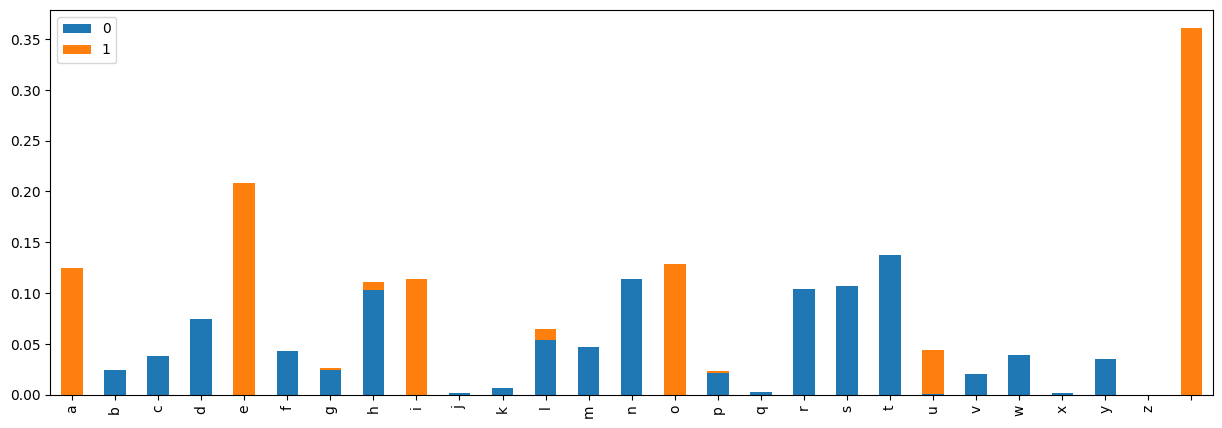

In [43]:
ax = emission_table.plot.bar(stacked=True, figsize=(15,5))

What has the algorithm discovered? Can you explain what the two states are, based on the emission probabilities they give to different letters? 

If you don't see any explainable pattern, then go back and try doing training again (see the cell above that says, "This is the cell that you would re-run..."). Since we initialize the training at a different random starting point each time, we don't always get the same results. Nevertheless, the process often converges to an interesting model with a clear linguistic explanation.

If you have time, try running the experiment again with a different number of states and/or including apostrophe and (condensed) punctuation. (The code below encorporates both those changes.) Can you find explanations for the states when you have a larger $N$?

In [44]:
alphabet = "abcdefghijklmnopqrstuvwxyz ':"
punctuation = ".;:,!?"  # Punctuation symbols we accept
alphabet_to_index = { alphabet[i]:i for i in range(len(alphabet)) }
source_file = open('roni.txt')
observations = []
for line in source_file :
    for c in line :
        c = c.lower()
        if c in alphabet :
            observations.append(alphabet_to_index[c])
        elif c in punctuation :  # Convert each punctuation symbol to ;
            observations.append(len(alphabet)-1)


FileNotFoundError: [Errno 2] No such file or directory: 'roni.txt'

In [ ]:
(pi, a, b) = train(3, len(alphabet), observations)
os.system("printf '\a'") # Beep when we're done

In [ ]:
N = 3
emission_table = pd.DataFrame({alphabet[k]: [round(math.exp(b[i][k]),4) for i in range(N)] 
                               for k in range(len(alphabet))}).transpose()

display(emission_table)

In [ ]:
ax = emission_table.plot.bar(stacked=True, figsize=(15,5))